In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import os 
from synth_pat.paths import Paths

In [5]:
demo = pd.read_csv(f'{Paths.DATA}/full_demographics.csv', index_col = 'SubjectID')

In [55]:
list1 = ['sub-2015060902', 'sub-2015121001', 'sub-2019012101', 'sub-2019052301', 'sub-2015060401', 'sub-2015061901', 'sub-2015111402', 'sub-2019012402', 'sub-2019052302']
list2 = ['sub-2015052501', 'sub-2015120501', 'sub-2015120401']
list3 = [pid for pid in os.listdir(f'{Paths.RESULTS}') if pid not in list1+list2]

type_of_sweep = 'bold_sweep'
type_of_ext = 'traditional'

emp_data_feat = pd.read_csv(f'{Paths.DATA}/ALL_{type_of_ext}_full_extracted_features.csv', index_col = 'pid')
emp_data_feat['diagnosis'] = demo['diagnosis']

In [56]:
mean_params = []
for pid in list3:
    pid_idx = int(pid.split('-')[1])
    file = f'{Paths.RESULTS}/{pid}/{type_of_sweep}_{type_of_ext}_estimated_mean_params.npz'
    mean_file = np.load(file)
    mean_ws = float(mean_file['ws'])
    mean_ctx = float(mean_file['njdopa_ctx'])
    mean_str = float(mean_file['njdopa_str'])
    mean_params.append([mean_ws, mean_ctx, mean_str, *emp_data_feat.loc[pid_idx].values])


In [57]:
res_df = pd.DataFrame(data=mean_params, columns=['est_ws', 'est_njdopa_ctx', 'est_njdopa_str', *emp_data_feat.columns])
res_df.drop(columns=['Unnamed: 0'], inplace=True)

In [58]:
print(res_df['est_ws'].dtype)
print(type(res_df['est_ws'].iloc[0]))

float64
<class 'numpy.float64'>


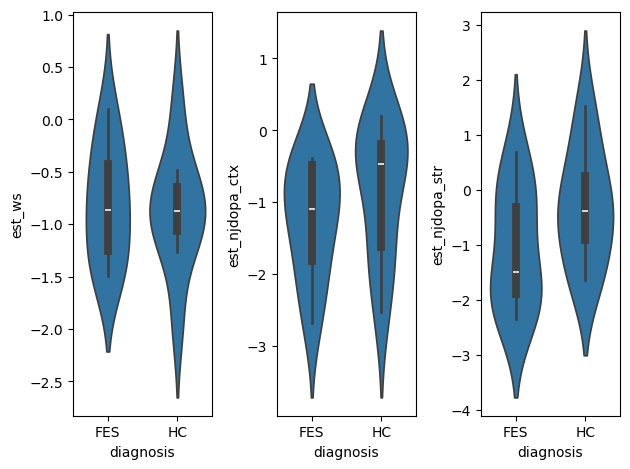

In [59]:
fig, axes = plt.subplots(1, 3)
params = ['est_ws', 'est_njdopa_ctx', 'est_njdopa_str']
for i, p in enumerate(params):
    sns.violinplot(
        data=res_df,
        x='diagnosis',
        y=p,
        ax=axes[i]
    )

plt.tight_layout()

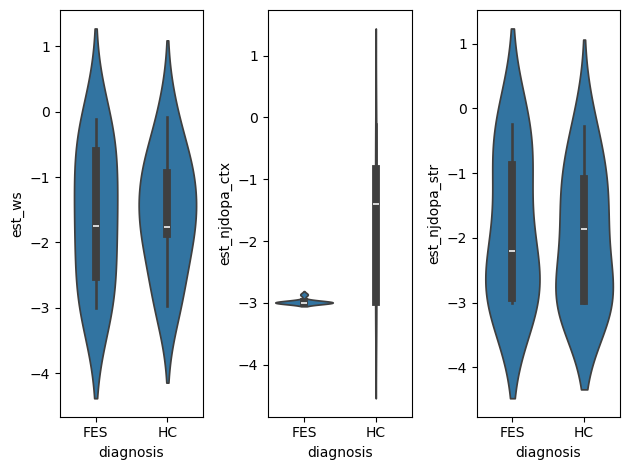

In [49]:
mean_params = []
for pid in list3:
    pid_idx = int(pid.split('-')[1])
    file = f'{Paths.RESULTS}/{pid}/{type_of_sweep}_{type_of_ext}_estimated_mode_params.npz'
    mean_file = np.load(file)
    mean_ws = float(mean_file['ws'])
    mean_ctx = float(mean_file['njdopa_ctx'])
    mean_str = float(mean_file['njdopa_str'])
    mean_params.append([mean_ws, mean_ctx, mean_str, *emp_data_feat.loc[pid_idx].values])

res_df = pd.DataFrame(data=mean_params, columns=['est_ws', 'est_njdopa_ctx', 'est_njdopa_str', *emp_data_feat.columns])
res_df.drop(columns=['Unnamed: 0'], inplace=True)

fig, axes = plt.subplots(1, 3)
params = ['est_ws', 'est_njdopa_ctx', 'est_njdopa_str']
for i, p in enumerate(params):
    sns.violinplot(
        data=res_df,
        x='diagnosis',
        y=p,
        ax=axes[i]
    )

plt.tight_layout()


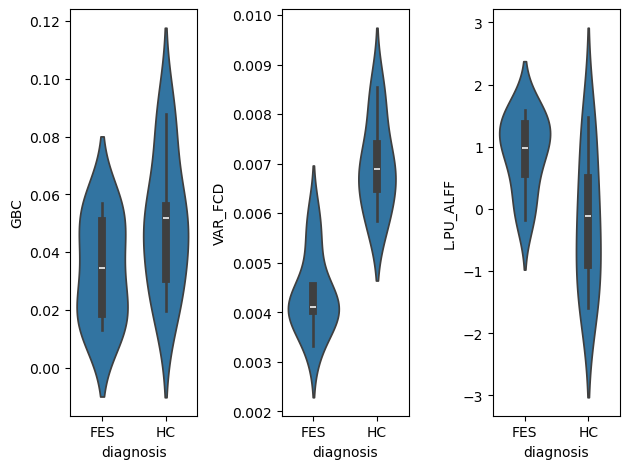

In [54]:
fig, axes = plt.subplots(1, 3)
params = ['GBC', 'VAR_FCD', 'L.PU_ALFF']
for i, p in enumerate(params):
    sns.violinplot(
        data=res_df,
        x='diagnosis',
        y=p,
        ax=axes[i]
    )

plt.tight_layout()


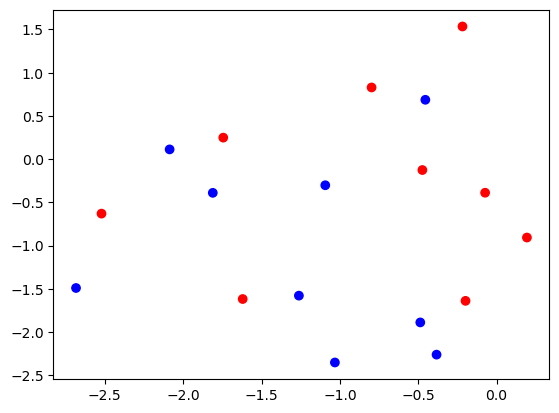

In [66]:
c = ['b' if res_df.loc[i, 'diagnosis'] == 'FES' else 'r'
     for i in res_df.index]
plt.scatter(res_df['est_njdopa_ctx'], res_df['est_njdopa_str'], c=c)

In [78]:
from scipy import stats
from sklearn.preprocessing import StandardScaler
## Using the internal function from SciPy Package  
sc = StandardScaler()
x = res_df[res_df['diagnosis']=='HC']['est_njdopa_str'].values.reshape(-1, 1)
y = res_df[res_df['diagnosis']=='FES']['est_njdopa_str'].values.reshape(-1, 1)
t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)  
print("t-statistic = " + str(t_stat))  
print("p-value = " + str(p_val))


t-statistic = [1.47590847]
p-value = [0.15940503]


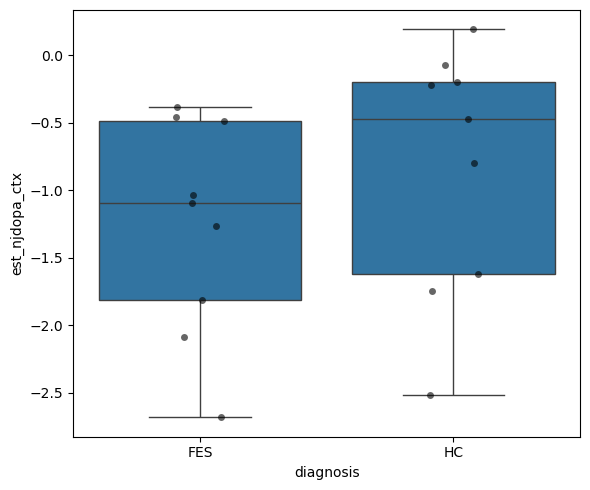

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.boxplot(data=res_df, x='diagnosis', y='est_njdopa_ctx')
sns.stripplot(data=res_df, x='diagnosis', y='est_njdopa_ctx',
              color='black', alpha=0.6)
plt.tight_layout()
plt.show()

In [85]:
from scipy import stats

x = res_df[res_df['diagnosis']=='HC']['est_njdopa_ctx'].values
y = res_df[res_df['diagnosis']=='FES']['est_njdopa_ctx'].values

t_stat, p_val = stats.ttest_ind(x, y, equal_var=False)

print("Welch t-test")
print("t =", t_stat)
print("p =", p_val)

Welch t-test
t = 1.047257461665443
p = 0.3108663851291279


In [86]:
u_stat, p_val_u = stats.mannwhitneyu(x, y, alternative='two-sided')

print("Mann-Whitney U test")
print("U =", u_stat)
print("p =", p_val_u)

Mann-Whitney U test
U = 56.0
p = 0.18532630419857943


In [87]:
import numpy as np

mean_diff = np.mean(x) - np.mean(y)
pooled_sd = np.sqrt((np.var(x, ddof=1) + np.var(y, ddof=1)) / 2)
cohens_d = mean_diff / pooled_sd

print("Cohen's d =", cohens_d)

Cohen's d = 0.49368190186123045
